# EDA and PREPROCESSING

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
import numpy as np
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import r2_score, mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX
import pmdarima as pm

In [3]:
df = pd.read_csv(r"D:\AI AND DATA SCIENCE\Time Series\ts_inference_engine\data\daily_gold_rate.csv")
df.head()

,Date,USD,EUR,GBP,INR,AED,CNY
0,1985-01-01,308.30,402.45,266.01,3825.85,1134.42,NaN
1,1985-01-02,305.50,401.49,266.00,3787.05,1134.42,NaN
2,1985-01-03,302.30,397.08,262.76,3718.88,1107.67,NaN
3,1985-01-04,303.15,397.15,262.58,3759.64,1118.21,NaN
4,1985-01-07,298.25,392.55,261.17,3741.23,1091.58,835.8


In [4]:
df.drop(columns=['EUR',	'GBP',	'INR',	'AED',	'CNY'], inplace=True)
df.head()

,Date,USD
0,1985-01-01,308.30
1,1985-01-02,305.50
2,1985-01-03,302.30
3,1985-01-04,303.15
4,1985-01-07,298.25


In [5]:
df.isna().sum()

Date    0
USD     0
dtype: int64

In [6]:
df['RP'] = df['USD'] * 16.886
df.head()

,Date,USD,RP
0,1985-01-01,308.30,5205.9538
1,1985-01-02,305.50,5158.6730
2,1985-01-03,302.30,5104.6378
3,1985-01-04,303.15,5118.9909
4,1985-01-07,298.25,5036.2495


In [7]:
df['Date'] = pd.to_datetime(df['Date'])
df.head()

,Date,USD,RP
0,1985-01-01,308.30,5205.9538
1,1985-01-02,305.50,5158.6730
2,1985-01-03,302.30,5104.6378
3,1985-01-04,303.15,5118.9909
4,1985-01-07,298.25,5036.2495


In [8]:
df.shape

(10114, 3)

In [9]:
df.drop(columns=['USD'], inplace=True)
df.head()

,Date,RP
0,1985-01-01,5205.9538
1,1985-01-02,5158.6730
2,1985-01-03,5104.6378
3,1985-01-04,5118.9909
4,1985-01-07,5036.2495


In [9]:
df.to_csv(r"D:\AI AND DATA SCIENCE\Time Series\ts_inference_engine\data_RP.csv", index=False)

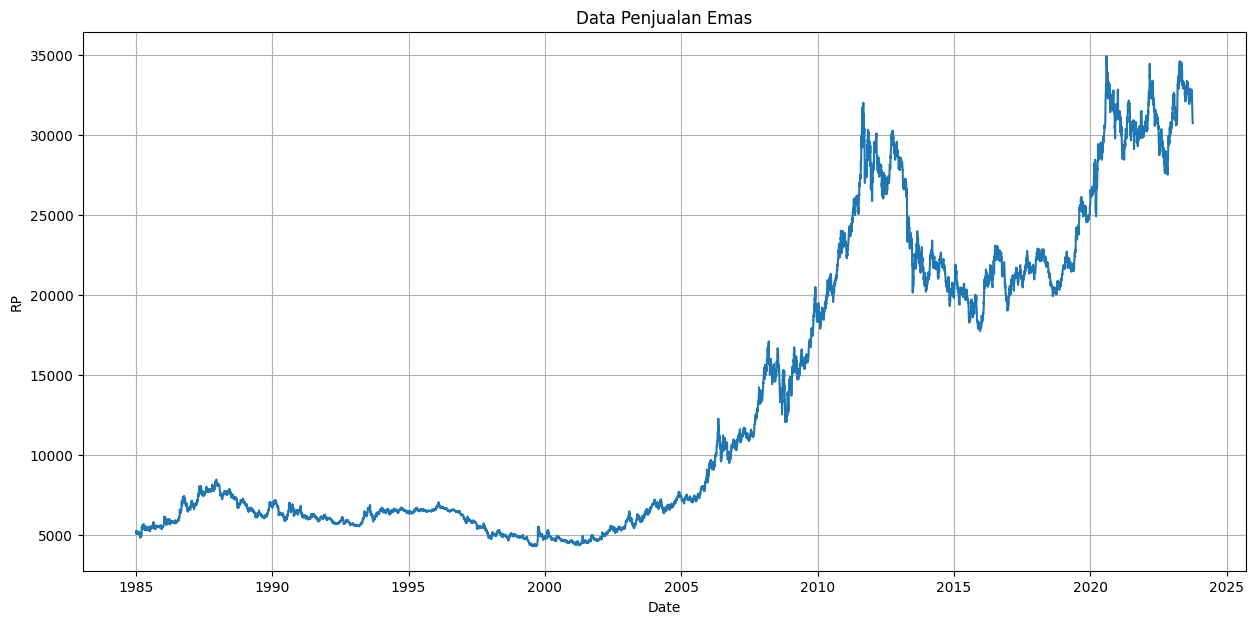

In [10]:
plt.figure(figsize=(15,7))
sns.lineplot(df, y='RP', x='Date')
plt.title("Data Penjualan Emas")
plt.grid()
plt.show()

In [11]:
def check_stationarity(timeseries):
    result = adfuller(timeseries)
    print('\n--- Hasil ADF Test ---')
    print(f'ADF Statistic: {result[0]}')
    print(f'p-value: {result[1]}')
    if result[1] <= 0.05:
        print("Kesimpulan: Data STASIONER (Bagus)")
    else:
        print("Kesimpulan: Data TIDAK STASIONER (Perlu Differencing/d)")

# ARIMA

In [12]:
df_arima = df.copy()
df_arima['RP_log'] = np.log1p(df_arima['RP'])

In [13]:
check_stationarity(df_arima['RP'])


--- Hasil ADF Test ---
ADF Statistic: 0.08926533923191715
p-value: 0.9653205005414078
Kesimpulan: Data TIDAK STASIONER (Perlu Differencing/d)


In [14]:
df_arima['RP_log_diff1'] = df_arima['RP_log'].diff()
df_diff_arima = df_arima.dropna()
df_diff_arima.head()

,Date,RP,RP_log,RP_log_diff1
1,1985-01-02,5158.6730,8.548628,-0.009122
2,1985-01-03,5104.6378,8.538101,-0.010528
3,1985-01-04,5118.9909,8.540908,0.002807
4,1985-01-07,5036.2495,8.524615,-0.016292
5,1985-01-08,5099.5720,8.537108,0.012492


In [15]:
check_stationarity(df_diff_arima['RP_log_diff1'])


--- Hasil ADF Test ---
ADF Statistic: -21.174311277115063
p-value: 0.0
Kesimpulan: Data STASIONER (Bagus)


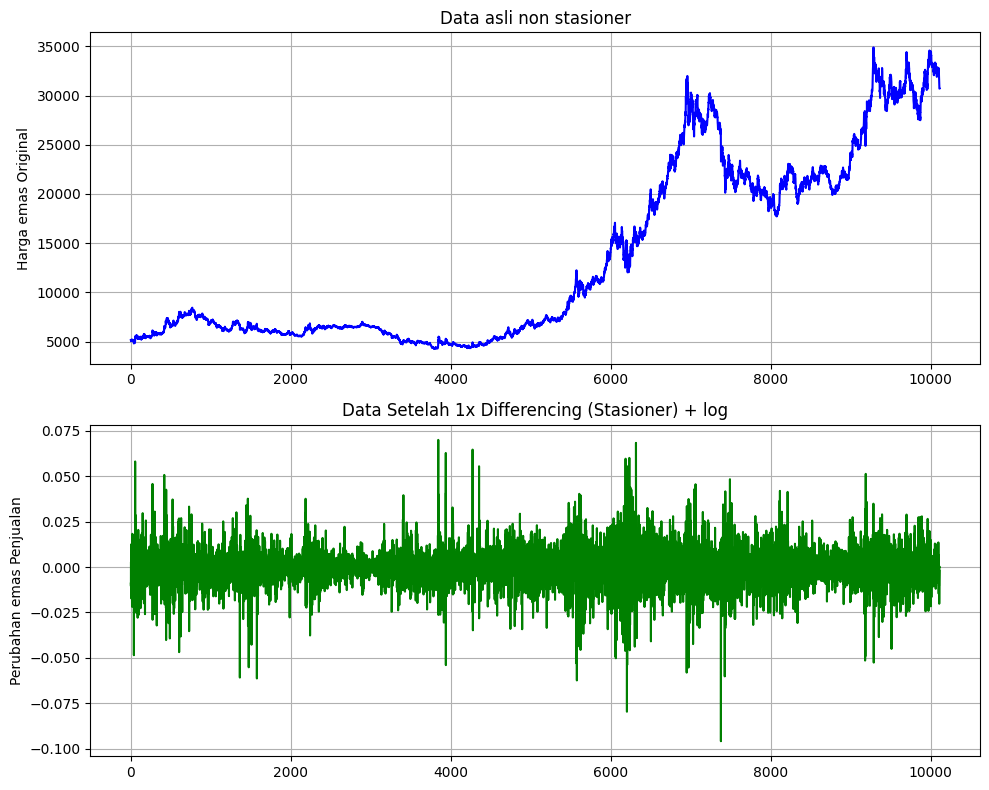

In [16]:
fig, ax = plt.subplots(2, 1, figsize=(10,8))

ax[0].plot(df_diff_arima['RP'], color='blue')
ax[0].set_title('Data asli non stasioner')
ax[0].set_ylabel('Harga emas Original')
ax[0].grid()

ax[1].plot(df_diff_arima['RP_log_diff1'], color='green')
ax[1].set_title('Data Setelah 1x Differencing (Stasioner) + log')
ax[1].set_ylabel('Perubahan emas Penjualan')
ax[1].grid()

plt.tight_layout()
plt.show()

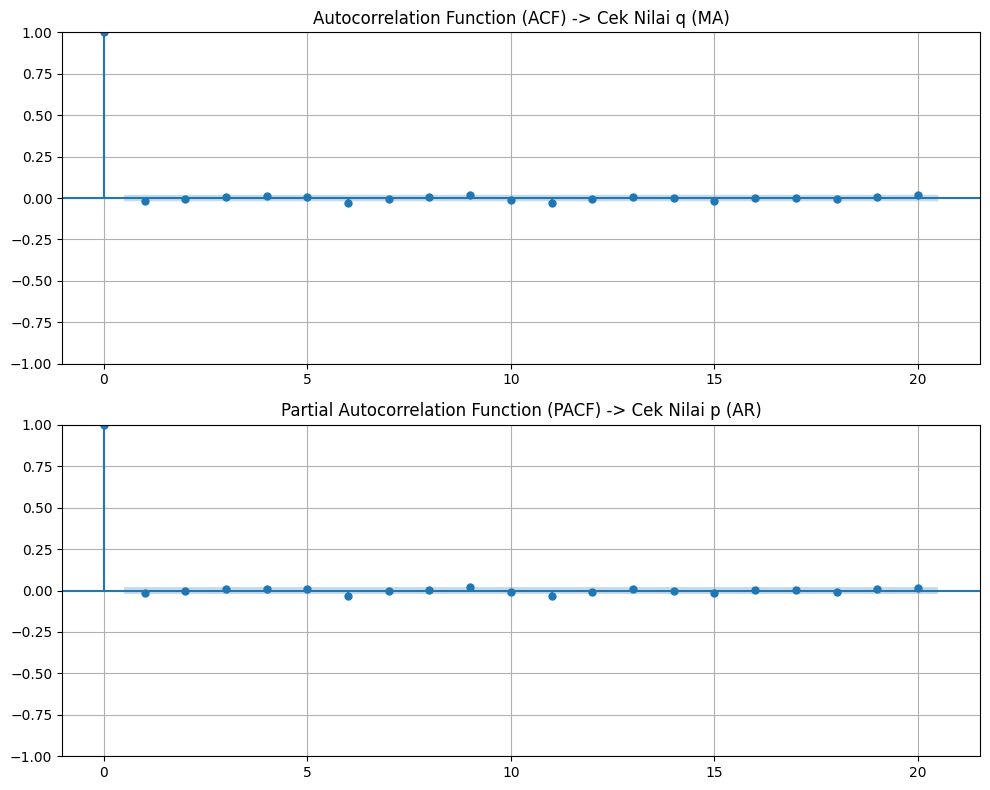

In [17]:
fig, ax = plt.subplots(2, 1, figsize=(10,8))

plot_acf(df_diff_arima['RP_log_diff1'], lags=20, ax=ax[0])
ax[0].set_title('Autocorrelation Function (ACF) -> Cek Nilai q (MA)')
ax[0].grid()

plot_pacf(df_diff_arima['RP_log_diff1'], lags=20, ax=ax[1])
ax[1].set_title('Partial Autocorrelation Function (PACF) -> Cek Nilai p (AR)')
ax[1].grid()

plt.tight_layout()
plt.show()

In [18]:
train_size = int(len(df_diff_arima)*0.8)
train_data, test_data = df_diff_arima[0:train_size], df_diff_arima[train_size:len(df_diff_arima)]
print(df_diff_arima.shape)
print(train_data.shape)
print(test_data.shape)

(10113, 4)
(8090, 4)
(2023, 4)


In [19]:
order = (0,1,0)
print(f'\nMelatih Model ARIMA dengan order {order}...')
model = ARIMA(train_data['RP_log'], order=order)
model_fit = model.fit()
print(model_fit.summary())


Melatih Model ARIMA dengan order (0, 1, 0)...


d:\python 3.11\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
d:\python 3.11\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
d:\python 3.11\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                 RP_log   No. Observations:                 8090
Model:                 ARIMA(0, 1, 0)   Log Likelihood               25822.048
Date:                Wed, 25 Feb 2026   AIC                         -51642.096
Time:                        01:16:05   BIC                         -51635.098
Sample:                             0   HQIC                        -51639.702
                               - 8090                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2      9.879e-05   7.39e-07    133.615      0.000    9.73e-05       0.000
Ljung-Box (L1) (Q):                   2.04   Jarque-Bera (JB):             15833.83
Prob(Q):                              0.15   Pr

In [20]:
forecast_result = model_fit.get_forecast(steps=len(test_data))
forecast_values = np.expm1(forecast_result.predicted_mean)
conf_int = np.expm1(forecast_result.conf_int())

forecast_series = pd.Series(forecast_values.values, index=test_data['Date'])
forecast_series.head(20)

d:\python 3.11\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
d:\python 3.11\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


Date
2016-01-06    18186.222
2016-01-07    18186.222
2016-01-08    18186.222
2016-01-11    18186.222
2016-01-12    18186.222
2016-01-13    18186.222
2016-01-14    18186.222
2016-01-15    18186.222
2016-01-18    18186.222
2016-01-19    18186.222
2016-01-20    18186.222
2016-01-21    18186.222
2016-01-22    18186.222
2016-01-25    18186.222
2016-01-26    18186.222
2016-01-27    18186.222
2016-01-28    18186.222
2016-01-29    18186.222
2016-02-01    18186.222
2016-02-02    18186.222
dtype: float64

In [21]:
order = (0,1,0)
print(f'\nMelatih Model ARIMA dengan order {order}...')
model_t = ARIMA(train_data['RP_log'], order=order, trend='t')
model_fit_t = model_t.fit()
print(model_fit_t.summary())


Melatih Model ARIMA dengan order (0, 1, 0)...


d:\python 3.11\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
d:\python 3.11\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
d:\python 3.11\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                 RP_log   No. Observations:                 8090
Model:                 ARIMA(0, 1, 0)   Log Likelihood               25823.039
Date:                Wed, 25 Feb 2026   AIC                         -51642.077
Time:                        01:16:05   BIC                         -51628.081
Sample:                             0   HQIC                        -51637.289
                               - 8090                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1             0.0002      0.000      1.360      0.174   -6.65e-05       0.000
sigma2      9.886e-05   7.42e-07    133.299      0.000    9.74e-05       0.000
Ljung-Box (L1) (Q):                   2.04   Jarque-

In [22]:
test_data.head()

,Date,RP,RP_log,RP_log_diff1
8091,2016-01-06,18429.3804,9.821756,0.013281
8092,2016-01-07,18681.8261,9.835360,0.013604
8093,2016-01-08,18605.8391,9.831284,-0.004076
8094,2016-01-11,18587.2645,9.830286,-0.000999
8095,2016-01-12,18328.0644,9.816243,-0.014042


In [23]:
rmse_arima = np.sqrt(mean_squared_error(test_data['RP'], forecast_series))
r2_arima = r2_score(test_data['RP'], forecast_series)
print(f'\nRoot Mean Squared Error (RMSE): {rmse_arima:.2f}')
print(f'R-squared (R²): {r2_arima:.4f}')


Root Mean Squared Error (RMSE): 9259.04
R-squared (R²): -2.8096


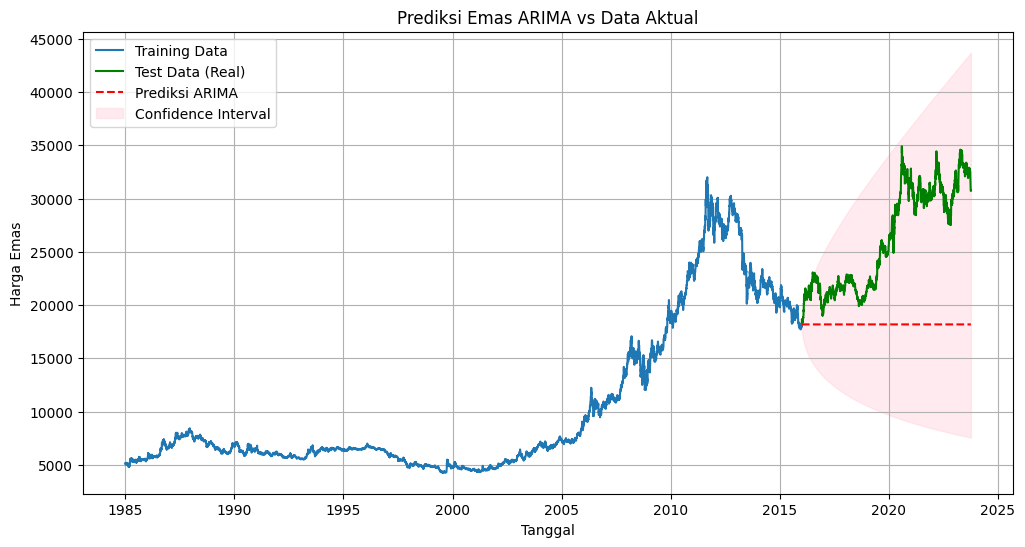

In [24]:
plt.figure(figsize=(12, 6))
plt.plot(train_data['Date'], train_data['RP'], label='Training Data')
plt.plot(test_data['Date'], test_data['RP'], label='Test Data (Real)', color='green')
plt.plot(forecast_series.index, forecast_series, label='Prediksi ARIMA', color='red', linestyle='--')

plt.fill_between(test_data['Date'],
                 conf_int.iloc[:, 0],
                 conf_int.iloc[:, 1], color='pink', alpha=0.3, label='Confidence Interval')

plt.title('Prediksi Emas ARIMA vs Data Aktual')
plt.xlabel('Tanggal')
plt.ylabel('Harga Emas')
plt.legend()
plt.grid(True)
plt.show()

In [25]:
model_fit.save(r'D:\AI AND DATA SCIENCE\Time Series\ts_inference_engine\artifacts\arima.pkl')
print("Model berhasil disimpan!")

Model berhasil disimpan!


# SARIMA

In [26]:
print("Sedang mencari order SARIMA terbaik...")

Sedang mencari order SARIMA terbaik...


In [27]:
model_auto = pm.auto_arima(
    train_data['RP_log'],
    start_p=0,
    start_q=0,
    max_p=3,
    max_q=3,
    m=5,
    start_P=0,
    seasonal=True,
    d=1,
    D=0,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True
)
print(model_auto.summary())

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,1)[5] intercept   : AIC=-51640.518, Time=0.85 sec
 ARIMA(0,1,0)(0,0,0)[5] intercept   : AIC=-51642.082, Time=0.42 sec
 ARIMA(1,1,0)(1,0,0)[5] intercept   : AIC=-51640.580, Time=0.89 sec
 ARIMA(0,1,1)(0,0,1)[5] intercept   : AIC=-51640.580, Time=0.93 sec
 ARIMA(0,1,0)(0,0,0)[5]             : AIC=-51642.096, Time=0.18 sec
 ARIMA(0,1,0)(1,0,0)[5] intercept   : AIC=-51640.546, Time=0.34 sec
 ARIMA(0,1,0)(1,0,1)[5] intercept   : AIC=-51636.569, Time=1.90 sec
 ARIMA(1,1,0)(0,0,0)[5] intercept   : AIC=-51642.124, Time=0.52 sec
 ARIMA(1,1,0)(0,0,1)[5] intercept   : AIC=-51640.555, Time=0.63 sec
 ARIMA(1,1,0)(1,0,1)[5] intercept   : AIC=-51636.530, Time=2.30 sec
 ARIMA(2,1,0)(0,0,0)[5] intercept   : AIC=-51640.481, Time=0.33 sec
 ARIMA(1,1,1)(0,0,0)[5] intercept   : AIC=-51640.220, Time=0.74 sec
 ARIMA(0,1,1)(0,0,0)[5] intercept   : AIC=-51642.148, Time=0.30 sec
 ARIMA(0,1,1)(1,0,0)[5] intercept   : AIC=-51640.603, Time=0.50 sec
 ARIM

In [28]:
# Best model:  ARIMA(0,1,0)(2,1,0)[5]
order = (0,1,0)
seasonal_order = (2,0,0,5)
model_sarima = SARIMAX(train_data['RP_log'],
                       order=order,
                       seasonal_order=seasonal_order,
                       trend='t')
results_sarima = model_sarima.fit()

d:\python 3.11\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
d:\python 3.11\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
d:\python 3.11\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [29]:
forecast_result_sarima = results_sarima.get_forecast(steps=len(test_data))
forecast_values_sarima = np.expm1(forecast_result_sarima.predicted_mean)
conf_int_sarima = np.expm1(forecast_result_sarima.conf_int())

forecast_series_sarima = pd.Series(forecast_values_sarima.values, index=test_data['Date'])
forecast_series_sarima.head(20)

d:\python 3.11\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
d:\python 3.11\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


Date
2016-01-06    18190.358704
2016-01-07    18195.413870
2016-01-08    18200.471065
2016-01-11    18208.371620
2016-01-12    18212.662446
2016-01-13    18218.337849
2016-01-14    18223.441959
2016-01-15    18228.548130
2016-01-18    18232.405281
2016-01-19    18237.807368
2016-01-20    18242.910118
2016-01-21    18248.007521
2016-01-22    18253.106977
2016-01-25    18258.189504
2016-01-26    18263.297861
2016-01-27    18268.401349
2016-01-28    18273.508771
2016-01-29    18278.618251
2016-02-01    18283.733861
2016-02-02    18288.846513
dtype: float64

In [30]:
rmse_sarima = np.sqrt(mean_squared_error(test_data['RP'], forecast_series_sarima))
r2_sarima = r2_score(test_data['RP'], forecast_series_sarima)
print(f'\nSarima Root Mean Squared Error (RMSE): {rmse_sarima:.2f}')
print(f'Sarima R-squared (R²): {r2_sarima:.4f}')


Sarima Root Mean Squared Error (RMSE): 2354.70
Sarima R-squared (R²): 0.7536


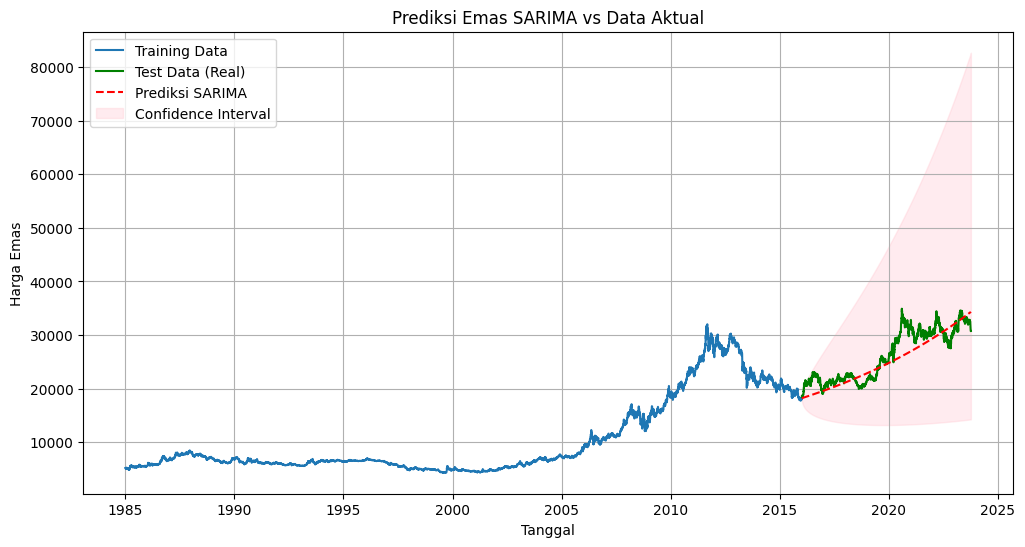

In [31]:
plt.figure(figsize=(12, 6))
plt.plot(train_data['Date'], train_data['RP'], label='Training Data')
plt.plot(test_data['Date'], test_data['RP'], label='Test Data (Real)', color='green')
plt.plot(forecast_series_sarima.index, forecast_series_sarima, label='Prediksi SARIMA', color='red', linestyle='--')

plt.fill_between(test_data['Date'],
                 conf_int_sarima.iloc[:, 0],
                 conf_int_sarima.iloc[:, 1], color='pink', alpha=0.3, label='Confidence Interval')

plt.title('Prediksi Emas SARIMA vs Data Aktual')
plt.xlabel('Tanggal')
plt.ylabel('Harga Emas')
plt.legend()
plt.grid(True)
plt.show()

In [32]:
results_sarima.save(r'D:\AI AND DATA SCIENCE\Time Series\ts_inference_engine\artifacts\sarima.pkl')
print("Model berhasil disimpan!")

Model berhasil disimpan!
